# Track A — Notebook 3: Entropy Analysis + Track C Handoff
**CS 639 · UW–Madison · Spring 2026 · ViT Hallucination Research**

---

| Item | Detail |
|------|--------|
| **Goal** | Statistical tests, report figures, export `entropy_ranks.csv` |
| **Input** | `chair_labels.csv` (NB1) + `rollout_data_complete.npz` (NB2) |
| **Output** | `entropy_ranks.csv` → **Track C (Day 6)** + 4 report figures |
| **GPU** | Not needed — CPU only, ~2 minutes |


## Cell 1 — Mount Drive + Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, pandas as pd
OUTPUT_DIR = "/content/drive/MyDrive/CS639_TrackA"

for f in ['chair_labels.csv', 'rollout_data_complete.npz']:
    assert os.path.exists(f"{OUTPUT_DIR}/{f}"), f"❌ {f} not found!"

chair_df = pd.read_csv(f"{OUTPUT_DIR}/chair_labels.csv")
rd = np.load(f"{OUTPUT_DIR}/rollout_data_complete.npz", allow_pickle=True)

image_ids  = rd['image_ids']
rollouts   = rd['rollouts']
entropies  = rd['entropies']
layer_ents = rd['layer_entropies'] if 'layer_entropies' in rd else None
spreads    = rd['spatial_spreads'] if 'spatial_spreads' in rd else None

print(f"✅ CHAIR: {len(chair_df)} | Rollouts: {rollouts.shape} | Entropies: {entropies.shape}")


Mounted at /content/drive
✅ CHAIR: 500 | Rollouts: (500, 576) | Entropies: (500,)


## Cell 2 — Build Master DataFrame

In [ ]:
rdf = pd.DataFrame({'image_id': image_ids, 'entropy': entropies})
if spreads is not None:
    rdf['spatial_spread'] = spreads

master_df = rdf.merge(
    chair_df[['image_id','file_name','chair_i','is_hallucinating',
              'n_mentioned','n_hallucinated','hallucinated_objects']],
    on='image_id', how='inner')
master_df = master_df[(master_df['entropy']>=0)&(master_df['chair_i']>=0)].reset_index(drop=True)
master_df['entropy_quartile'] = pd.qcut(master_df['entropy'], q=4, labels=[1,2,3,4]).astype(int)

print(f"Master: {len(master_df)} valid images")
print(f"\nHallucination rate by entropy quartile:")
print(master_df.groupby('entropy_quartile')['is_hallucinating'].mean().round(3).to_string())


Master: 500 valid images

Hallucination rate by entropy quartile:
entropy_quartile
1    0.616
2    0.688
3    0.688
4    0.640


## Cell 3 — Statistical Tests

In [ ]:
from scipy.stats import spearmanr, mannwhitneyu
import numpy as np

hall_e  = master_df[master_df['is_hallucinating']==True]['entropy'].values
clean_e = master_df[master_df['is_hallucinating']==False]['entropy'].values

rho, p_sp = spearmanr(master_df['entropy'], master_df['chair_i'])
u_stat, p_mw = mannwhitneyu(hall_e, clean_e, alternative='greater')
pooled = np.sqrt((hall_e.std()**2 + clean_e.std()**2) / 2)
d = (hall_e.mean() - clean_e.mean()) / (pooled + 1e-8)
eff = 'negligible' if abs(d)<0.2 else 'small' if abs(d)<0.5 else 'medium' if abs(d)<0.8 else 'large'

print("="*60)
print("TRACK A — STATISTICAL RESULTS")
print("="*60)
print(f"\nSpearman ρ (entropy vs CHAIR_i): {rho:.4f}  (p = {p_sp:.6f})")
if p_sp < 0.05:
    print(f"  → ✅ SIGNIFICANT {'POSITIVE' if rho>0 else 'NEGATIVE'} CORRELATION")
else:
    print(f"  → ❌ NOT SIGNIFICANT (null result)")
print(f"\nMann-Whitney U: p = {p_mw:.6f}")
print(f"  Mean(halluc): {hall_e.mean():.4f} | Mean(clean): {clean_e.mean():.4f} | Δ: {hall_e.mean()-clean_e.mean():.4f}")
print(f"\nCohen's d: {d:.4f} ({eff})")
print("="*60)


TRACK A — STATISTICAL RESULTS

Spearman ρ (entropy vs CHAIR_i): 0.0033  (p = 0.940549)
  → ❌ NOT SIGNIFICANT (null result)

Mann-Whitney U: p = 0.386520
  Mean(halluc): 6.3211 | Mean(clean): 6.3207 | Δ: 0.0005

Cohen's d: 0.0387 (negligible)


## Cell 4 — Figure 1: Entropy Distribution

/tmp/ipykernel_9880/892063834.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([clean_e, hall_e], labels=['Clean','Hallucinating'], patch_artist=True,


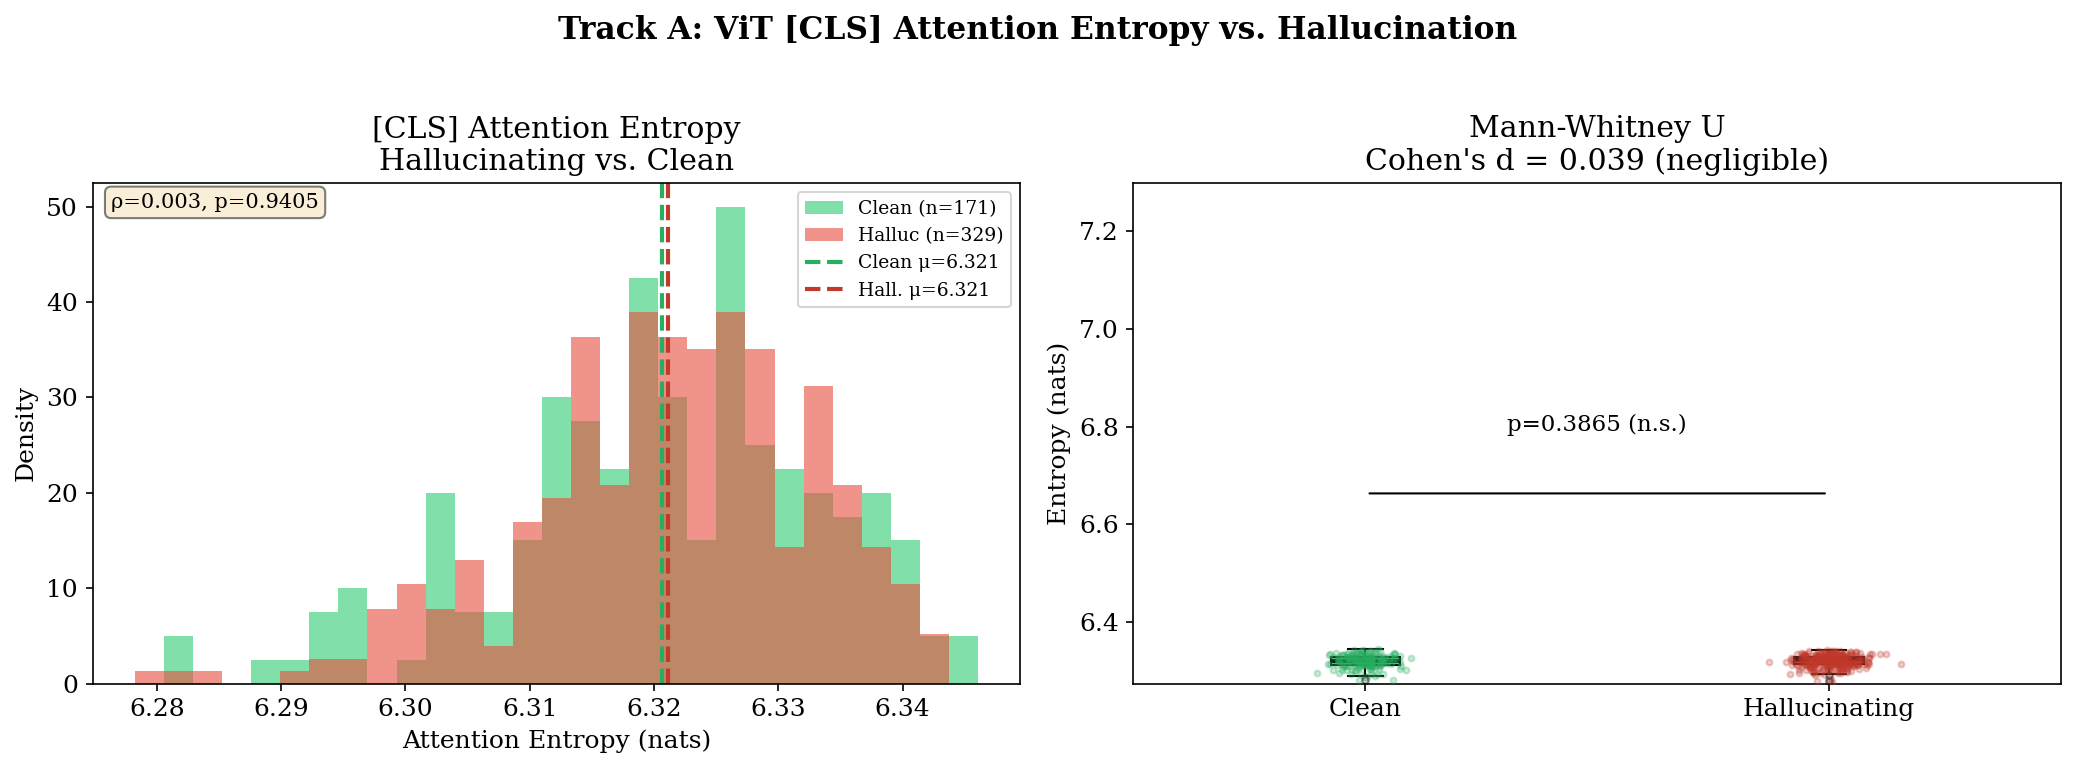

✅ Figure 1 saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'font.family':'serif','font.size':12,'figure.dpi':150})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(master_df['entropy'].min(), master_df['entropy'].max(), 30)

axes[0].hist(clean_e, bins=bins, alpha=0.6, color='#2ecc71', label=f'Clean (n={len(clean_e)})', density=True)
axes[0].hist(hall_e, bins=bins, alpha=0.6, color='#e74c3c', label=f'Halluc (n={len(hall_e)})', density=True)
axes[0].axvline(clean_e.mean(), color='#27ae60', ls='--', lw=2, label=f'Clean μ={clean_e.mean():.3f}')
axes[0].axvline(hall_e.mean(), color='#c0392b', ls='--', lw=2, label=f'Hall. μ={hall_e.mean():.3f}')
axes[0].set_xlabel('Attention Entropy (nats)'); axes[0].set_ylabel('Density')
axes[0].set_title('[CLS] Attention Entropy\nHallucinating vs. Clean')
axes[0].legend(fontsize=9)
axes[0].text(0.02,0.98, f'ρ={rho:.3f}, p={p_sp:.4f}', transform=axes[0].transAxes, va='top',
             fontsize=10, bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))

bp = axes[1].boxplot([clean_e, hall_e], labels=['Clean','Hallucinating'], patch_artist=True,
                     medianprops=dict(color='black',lw=2), flierprops=dict(marker='o',markersize=3,alpha=0.3))
bp['boxes'][0].set_facecolor('#2ecc7188'); bp['boxes'][1].set_facecolor('#e74c3c88')
np.random.seed(42)
axes[1].scatter(np.random.normal(1,0.04,len(clean_e)), clean_e, alpha=0.25, s=8, color='#27ae60', zorder=3)
axes[1].scatter(np.random.normal(2,0.04,len(hall_e)), hall_e, alpha=0.25, s=8, color='#c0392b', zorder=3)
ym = max(clean_e.max(), hall_e.max())
sig = f'p={p_mw:.4f}'+(' *' if p_mw<0.05 else ' (n.s.)')
axes[1].annotate('', xy=(2,ym*1.05), xytext=(1,ym*1.05), arrowprops=dict(arrowstyle='-',color='black'))
axes[1].text(1.5, ym*1.07, sig, ha='center', fontsize=11)
axes[1].set_ylabel('Entropy (nats)')
axes[1].set_title(f"Mann-Whitney U\nCohen's d = {d:.3f} ({eff})")
axes[1].set_ylim(top=ym*1.15)

plt.suptitle('Track A: ViT [CLS] Attention Entropy vs. Hallucination', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_entropy_distribution.png", bbox_inches='tight', dpi=150)
plt.show(); print("✅ Figure 1 saved.")


## Cell 5 — Figure 2: Spearman Scatter

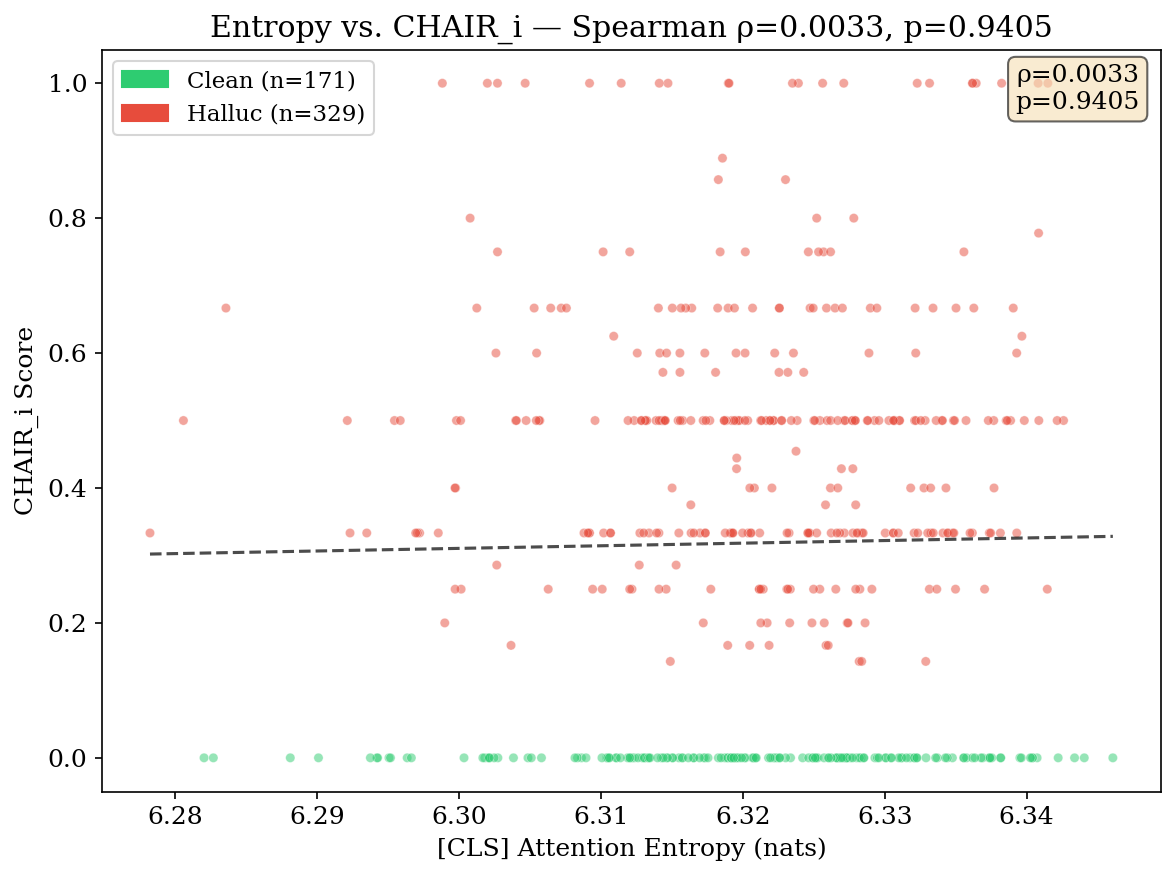

✅ Figure 2 saved.


In [ ]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))
colors = master_df['is_hallucinating'].map({True:'#e74c3c',False:'#2ecc71'})
ax.scatter(master_df['entropy'], master_df['chair_i'], c=colors, alpha=0.5, s=20, edgecolors='white', linewidths=0.3)

sl, ic, _, _, _ = linregress(master_df['entropy'], master_df['chair_i'])
xr = np.linspace(master_df['entropy'].min(), master_df['entropy'].max(), 100)
ax.plot(xr, sl*xr+ic, 'k--', lw=1.5, alpha=0.7)

ax.legend(handles=[mpatches.Patch(color='#2ecc71',label=f'Clean (n={len(clean_e)})'),
                   mpatches.Patch(color='#e74c3c',label=f'Halluc (n={len(hall_e)})')], fontsize=11)
ax.set_xlabel('[CLS] Attention Entropy (nats)'); ax.set_ylabel('CHAIR_i Score')
ax.set_title(f'Entropy vs. CHAIR_i — Spearman ρ={rho:.4f}, p={p_sp:.4f}')
ax.text(0.98,0.98, f'ρ={rho:.4f}\np={p_sp:.4f}', transform=ax.transAxes, ha='right', va='top',
        fontsize=12, bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.6))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_spearman_scatter.png", bbox_inches='tight', dpi=150)
plt.show(); print("✅ Figure 2 saved.")


## Cell 6 — Figure 3: Quartile Analysis

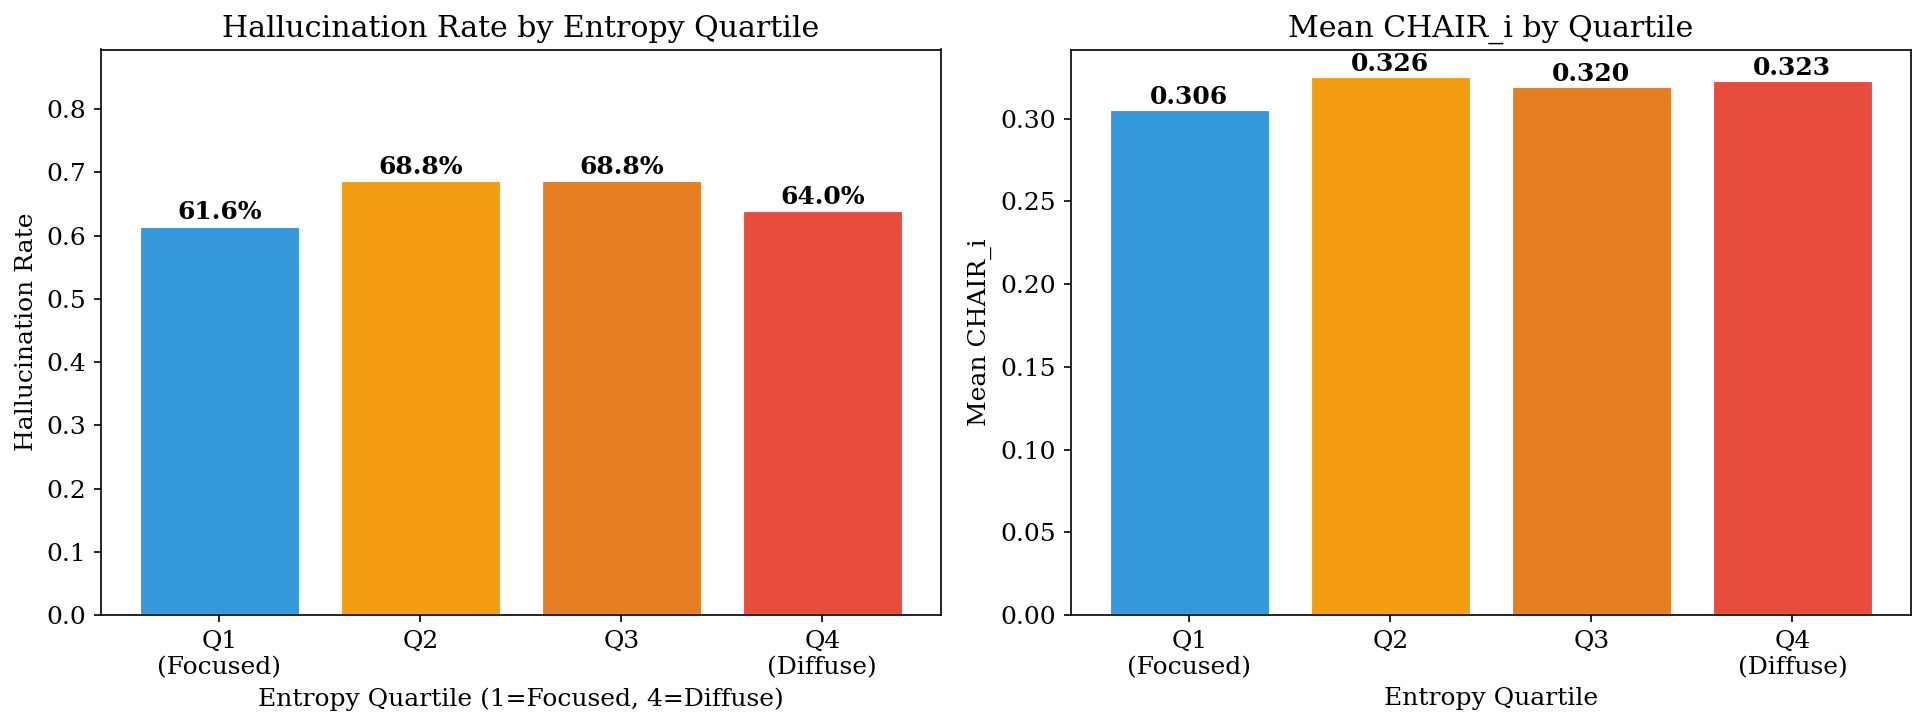


Quartile summary:
 entropy_quartile  hall_rate  mean_ent  mean_chair  count
                1      0.616  6.305172    0.305702    125
                2      0.688  6.318183    0.325626    125
                3      0.688  6.325624    0.319615    125
                4      0.640  6.334978    0.323429    125

✅ Figure 3 saved.


In [ ]:
qs = master_df.groupby('entropy_quartile').agg(
    hall_rate=('is_hallucinating','mean'), mean_ent=('entropy','mean'),
    mean_chair=('chair_i','mean'), count=('image_id','count')).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bc = ['#3498db','#f39c12','#e67e22','#e74c3c']

bars = axes[0].bar(qs['entropy_quartile'], qs['hall_rate'], color=bc, edgecolor='white', lw=1.5)
for b, v in zip(bars, qs['hall_rate']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0].set_xlabel('Entropy Quartile (1=Focused, 4=Diffuse)'); axes[0].set_ylabel('Hallucination Rate')
axes[0].set_title('Hallucination Rate by Entropy Quartile')
axes[0].set_xticks([1,2,3,4]); axes[0].set_xticklabels(['Q1\n(Focused)','Q2','Q3','Q4\n(Diffuse)'])
axes[0].set_ylim(0, max(qs['hall_rate'])*1.3)

bars2 = axes[1].bar(qs['entropy_quartile'], qs['mean_chair'], color=bc, edgecolor='white', lw=1.5)
for b, v in zip(bars2, qs['mean_chair']):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].set_xlabel('Entropy Quartile'); axes[1].set_ylabel('Mean CHAIR_i')
axes[1].set_title('Mean CHAIR_i by Quartile')
axes[1].set_xticks([1,2,3,4]); axes[1].set_xticklabels(['Q1\n(Focused)','Q2','Q3','Q4\n(Diffuse)'])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_quartile_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("\nQuartile summary:"); print(qs.to_string(index=False))
print("\n✅ Figure 3 saved.")


## Cell 7 — Figure 4: Per-Layer Entropy Curves

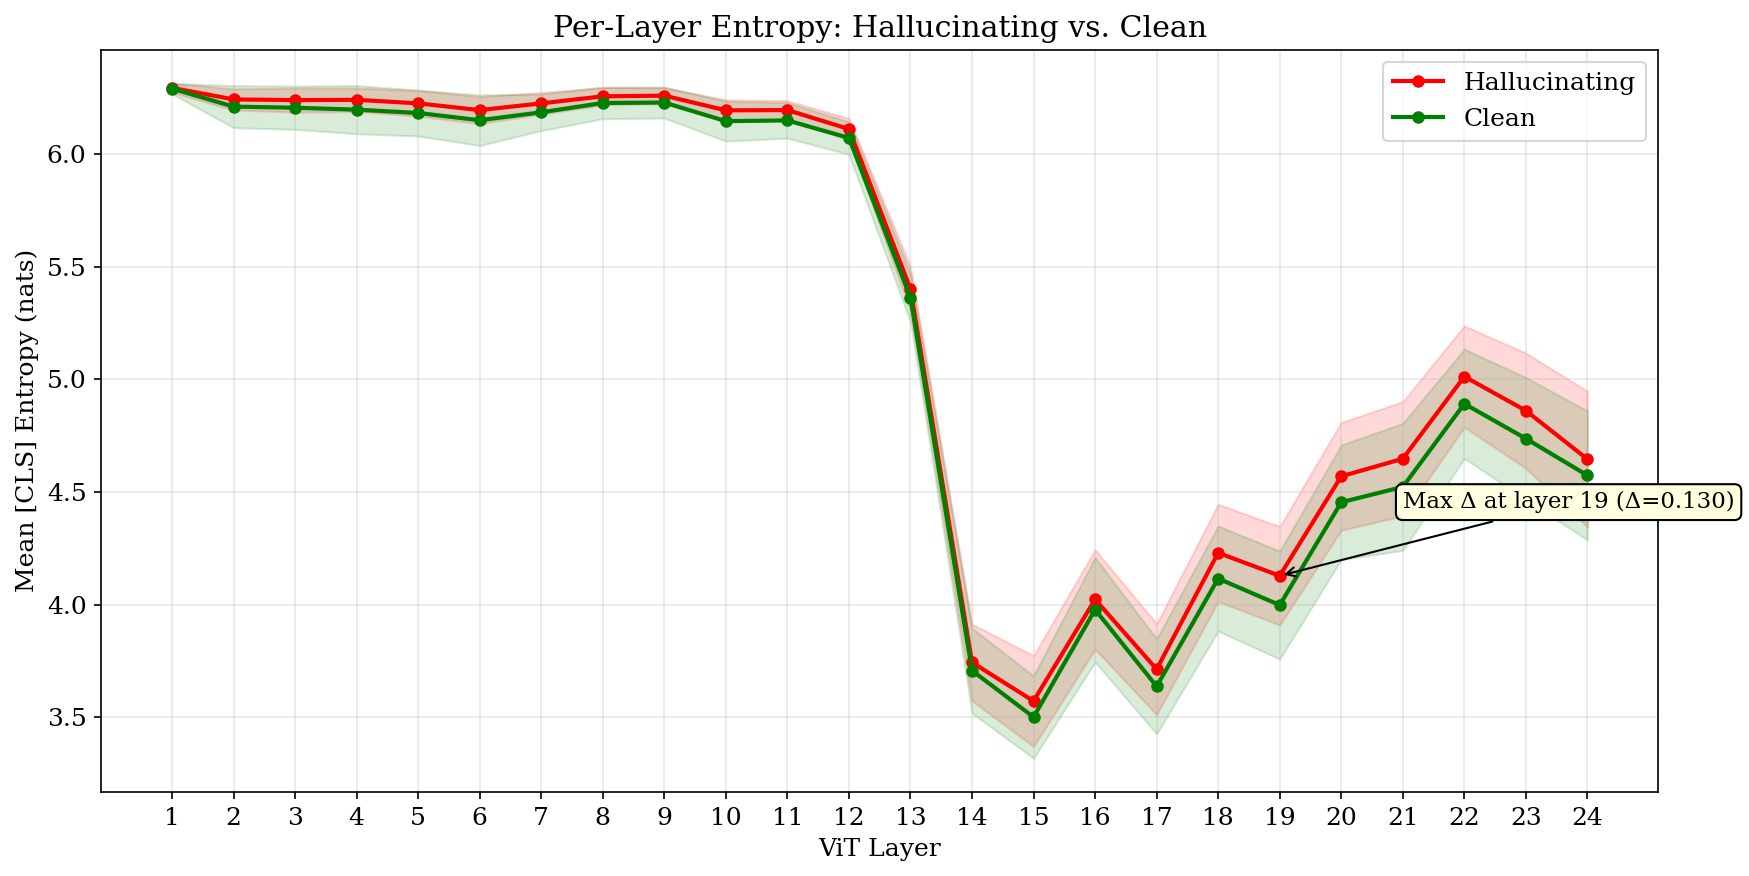

✅ Figure 4 saved.


In [ ]:
if layer_ents is not None and layer_ents.shape[1] == 24:
    ldf = pd.DataFrame({'image_id': image_ids})
    ldf = ldf.merge(master_df[['image_id','is_hallucinating']], on='image_id', how='inner')
    idx_map = {iid: i for i, iid in enumerate(image_ids)}
    vi = [idx_map[iid] for iid in ldf['image_id']]
    vl = layer_ents[vi]
    hm = ldf['is_hallucinating'].values

    x = np.arange(1, 25)
    fig, ax = plt.subplots(figsize=(12, 6))
    hmu, hsd = vl[hm].mean(0), vl[hm].std(0)
    cmu, csd = vl[~hm].mean(0), vl[~hm].std(0)
    ax.plot(x, hmu, 'r-o', label='Hallucinating', lw=2, ms=5)
    ax.fill_between(x, hmu-hsd, hmu+hsd, alpha=0.15, color='red')
    ax.plot(x, cmu, 'g-o', label='Clean', lw=2, ms=5)
    ax.fill_between(x, cmu-csd, cmu+csd, alpha=0.15, color='green')
    ax.set_xlabel('ViT Layer'); ax.set_ylabel('Mean [CLS] Entropy (nats)')
    ax.set_title('Per-Layer Entropy: Hallucinating vs. Clean'); ax.legend(fontsize=12)
    ax.set_xticks(x); ax.grid(True, alpha=0.3)
    gaps = hmu - cmu
    top = np.argmax(gaps)+1
    ax.annotate(f'Max Δ at layer {top} (Δ={gaps.max():.3f})',
                xy=(top, hmu[top-1]), xytext=(top+2, hmu[top-1]+0.3),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightyellow'))
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figure_per_layer_entropy.png", bbox_inches='tight', dpi=150)
    plt.show(); print("✅ Figure 4 saved.")
else:
    print("⚠️  Per-layer data not available. Skipping.")


## Cell 8 — Export `entropy_ranks.csv` (TRACK C HANDOFF)

In [ ]:
exp = master_df[['image_id','file_name','entropy','entropy_quartile',
                 'chair_i','is_hallucinating']].copy()
if 'spatial_spread' in master_df.columns:
    exp['spatial_spread'] = master_df['spatial_spread']

exp['entropy_rank'] = exp['entropy'].rank(method='average').astype(int)
exp['entropy_percentile'] = exp['entropy'].rank(pct=True)
exp['entropy_group'] = exp['entropy_quartile'].map(
    {1:'low_entropy', 2:'mid_low', 3:'mid_high', 4:'high_entropy'})
exp = exp.sort_values('entropy').reset_index(drop=True)

save = f"{OUTPUT_DIR}/entropy_ranks.csv"
exp.to_csv(save, index=False)

print(f"✅ Saved: {save}")
print(f"   Shape: {exp.shape}")
print(f"\nFirst 5 (most focused):"); print(exp.head().to_string(index=False))
print(f"\nLast 5 (most diffuse):"); print(exp.tail().to_string(index=False))
q1 = (exp['entropy_group']=='low_entropy').sum()
q4 = (exp['entropy_group']=='high_entropy').sum()
print(f"\nTrack C split: Q1={q1} images | Q4={q4} images")
print(f"\n{'='*60}")
print(f"✅ MILESTONE: entropy_ranks.csv ready for Track C handoff")
print(f"{'='*60}")


✅ Saved: /content/drive/MyDrive/CS639_TrackA/entropy_ranks.csv
   Shape: (500, 10)

First 5 (most focused):
 image_id        file_name  entropy  entropy_quartile  chair_i  is_hallucinating  spatial_spread  entropy_rank  entropy_percentile entropy_group
    27982 000000027982.jpg 6.278232                 1   0.3333              True        0.437136             1               0.002   low_entropy
   118594 000000118594.jpg 6.280588                 1   0.5000              True        0.418607             2               0.004   low_entropy
    85329 000000085329.jpg 6.282042                 1   0.0000             False        0.409678             3               0.006   low_entropy
   348216 000000348216.jpg 6.282696                 1   0.0000             False        0.435693             4               0.008   low_entropy
   249180 000000249180.jpg 6.283584                 1   0.6667              True        0.444325             5               0.010   low_entropy

Last 5 (most diffuse)

## Cell 9 — Complete Summary

In [ ]:
num_patches = rollouts.shape[1]
print("="*65)
print("  TRACK A — COMPLETE RESULTS")
print("="*65)
print(f"\n📊 DATASET: {len(master_df)} images")
print(f"   Hallucinating: {master_df['is_hallucinating'].sum()} ({master_df['is_hallucinating'].mean():.1%})")
print(f"   Clean:         {(~master_df['is_hallucinating']).sum()} ({(~master_df['is_hallucinating']).mean():.1%})")
print(f"\n🎯 CHAIR: Mean={master_df['chair_i'].mean():.4f} | Median={master_df['chair_i'].median():.4f}")
print(f"\n📈 ENTROPY: Mean={master_df['entropy'].mean():.4f} nats | Max possible={np.log(num_patches):.4f}")
print(f"   Halluc μ={hall_e.mean():.4f} | Clean μ={clean_e.mean():.4f} | Δ={hall_e.mean()-clean_e.mean():.4f}")
print(f"\n📐 STATS: Spearman ρ={rho:.4f} (p={p_sp:.6f}) | Cohen's d={d:.4f} ({eff})")
print(f"   Significant: {'YES ✅' if p_sp<0.05 else 'NO ❌'}")
print(f"\n📋 QUARTILE RATES:")
for _, r in qs.iterrows():
    q = int(r['entropy_quartile'])
    t = " (focused)" if q==1 else " (diffuse)" if q==4 else ""
    print(f"   Q{q}{t}: {r['hall_rate']:.1%} halluc, CHAIR_i={r['mean_chair']:.3f}")
print(f"\n📁 FILES:")
for f in ['chair_labels.csv','entropy_ranks.csv','rollout_data_complete.npz',
          'figure_entropy_distribution.png','figure_spearman_scatter.png',
          'figure_quartile_analysis.png','figure_per_layer_entropy.png']:
    e = os.path.exists(f"{OUTPUT_DIR}/{f}")
    print(f"   {'✅' if e else '⬜'} {f}")
print(f"\n{'='*65}")
print(f"   Track A COMPLETE")
print(f"   → chair_labels.csv    → Track B (Day 4)")
print(f"   → entropy_ranks.csv   → Track C (Day 6)")
print(f"{'='*65}")


  TRACK A — COMPLETE RESULTS

📊 DATASET: 500 images
   Hallucinating: 329 (65.8%)
   Clean:         171 (34.2%)

🎯 CHAIR: Mean=0.3186 | Median=0.3333

📈 ENTROPY: Mean=6.3210 nats | Max possible=6.3561
   Halluc μ=6.3211 | Clean μ=6.3207 | Δ=0.0005

📐 STATS: Spearman ρ=0.0033 (p=0.940549) | Cohen's d=0.0387 (negligible)
   Significant: NO ❌

📋 QUARTILE RATES:
   Q1 (focused): 61.6% halluc, CHAIR_i=0.306
   Q2: 68.8% halluc, CHAIR_i=0.326
   Q3: 68.8% halluc, CHAIR_i=0.320
   Q4 (diffuse): 64.0% halluc, CHAIR_i=0.323

📁 FILES:
   ✅ chair_labels.csv
   ✅ entropy_ranks.csv
   ✅ rollout_data_complete.npz
   ✅ figure_entropy_distribution.png
   ✅ figure_spearman_scatter.png
   ✅ figure_quartile_analysis.png
   ✅ figure_per_layer_entropy.png

   Track A COMPLETE
   → chair_labels.csv    → Track B (Day 4)
   → entropy_ranks.csv   → Track C (Day 6)


In [ ]:
# Cell 10 — Download All Track A Outputs
import shutil
import os
from google.colab import files

# Create a zip of everything
ZIP_NAME = "TrackA_Complete_Outputs"
ZIP_DIR = f"/content/{ZIP_NAME}"
os.makedirs(ZIP_DIR, exist_ok=True)

# Copy all output files
output_files = [
    "chair_labels.csv",
    "entropy_ranks.csv",
    "sampled_image_ids.json",
    "rollout_data_complete.npz",
    "chair_distribution.png",
    "figure_entropy_distribution.png",
    "figure_spearman_scatter.png",
    "figure_quartile_analysis.png",
    "figure_per_layer_entropy.png",
]

print("Collecting files...")
for f in output_files:
    src = f"{OUTPUT_DIR}/{f}"
    if os.path.exists(src):
        shutil.copy2(src, f"{ZIP_DIR}/{f}")
        print(f"  ✅ {f}")
    else:
        print(f"  ⬜ {f} (not found, skipping)")

# Copy attention visualizations folder
viz_dir = f"{OUTPUT_DIR}/attention_viz"
if os.path.exists(viz_dir):
    shutil.copytree(viz_dir, f"{ZIP_DIR}/attention_viz", dirs_exist_ok=True)
    n_viz = len(os.listdir(f"{ZIP_DIR}/attention_viz"))
    print(f"  ✅ attention_viz/ ({n_viz} images)")

# Create zip
print("\nZipping...")
shutil.make_archive(f"/content/{ZIP_NAME}", 'zip', "/content", ZIP_NAME)
zip_size = os.path.getsize(f"/content/{ZIP_NAME}.zip") / 1e6
print(f"✅ Created {ZIP_NAME}.zip ({zip_size:.1f} MB)")

# Auto-download to your machine
print("\nStarting download...")
files.download(f"/content/{ZIP_NAME}.zip")

  ✅ chair_labels.csv
  ✅ entropy_ranks.csv
  ✅ sampled_image_ids.json
  ✅ rollout_data_complete.npz
  ✅ chair_distribution.png
  ✅ figure_entropy_distribution.png
  ✅ figure_spearman_scatter.png
  ✅ figure_quartile_analysis.png
  ✅ figure_per_layer_entropy.png
  ✅ attention_viz/ (20 images)

Zipping...
✅ Created TrackA_Complete_Outputs.zip (15.9 MB)

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>